In [38]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import pandas as pd
from collections import Counter



In [17]:
def graficar_datos_y_neuronas(matriz, datos):
    filas, columnas = matriz.shape[:2]
    dim = matriz.shape[2]
    
    # Preparar un array de colores para las neuronas
    num_neuronas = filas * columnas
    colores = plt.cm.get_cmap('tab20', num_neuronas)
    
    # Para cada dato, encontrar la neurona ganadora
    bmu_indices = np.zeros(len(datos), dtype=int)
    for idx, x in enumerate(datos):
        distancias = np.linalg.norm(matriz - x, axis=2)
        bmu = np.unravel_index(np.argmin(distancias), distancias.shape)
        # Convertir índice 2D de neurona a un índice único para color
        bmu_indices[idx] = bmu[0] * columnas + bmu[1]
    
    # Graficar los datos coloreados según su neurona ganadora
    plt.figure(figsize=(7,7))
    for i in range(num_neuronas):
        plt.scatter(datos[bmu_indices==i, 0], datos[bmu_indices==i, 1], 
                    color=colores(i), s=15, alpha=0.6)
    
    # Graficar las neuronas como centroides
    for i in range(filas):
        for j in range(columnas):
            w = matriz[i, j]
            idx = i * columnas + j   # índice único para cada neurona
            plt.scatter(w[0], w[1], color=colores(idx), marker='o', s=90, edgecolors='k')

    # Dibujar líneas entre neuronas vecinas
    for i in range(filas):
        for j in range(columnas):
            if i+1 < filas:  # vecino de abajo
                plt.plot([matriz[i,j,0], matriz[i+1,j,0]], [matriz[i,j,1], matriz[i+1,j,1]], 'k-', linewidth=0.5)
            if j+1 < columnas:  # vecino de la derecha
                plt.plot([matriz[i,j,0], matriz[i,j+1,0]], [matriz[i,j,1], matriz[i,j+1,1]], 'k-', linewidth=0.5)



    
    plt.title('Datos coloreados según neurona ganadora y centroides de neuronas')
    plt.xlabel('Componente 1')
    plt.ylabel('Componente 2')
    plt.grid(True)
    plt.show()


In [ ]:
def matriz_vectores_2d(filas, columnas, dimension):
    matriz = np.random.uniform(-0.5, 0.5, (filas, columnas, dimension))
    return matriz


In [ ]:
def actualizar_pesos(matriz, x, tasa_de_aprendizaje, radio_vecindad):
    """
    matriz: SOM, puede ser 1D (num_neuronas, dim) o 2D (filas, columnas, dim)
    x: vector de entrada
    tasa_de_aprendizaje: eta
    radio_vecindad: r
    """
    
    # Detectar si es 1D o 2D
    if matriz.ndim == 2:
        # SOM 1D
        distancias = np.linalg.norm(matriz - x, axis=1)
        indice_distancia_minima = np.argmin(distancias)

        # Vecindad lineal
        for idx in range(max(0, indice_distancia_minima - radio_vecindad), min(matriz.shape[0], indice_distancia_minima + radio_vecindad + 1)): #max → evita índices negativos (antes del primer elemento). min → evita índices mayores que el tamaño de la matriz.
            matriz[idx] += tasa_de_aprendizaje * (x - matriz[idx])
    
    elif matriz.ndim == 3:
        # SOM 2D
        filas, columnas = matriz.shape[:2]
        distancia_min = -1
        for i in range(filas):
            for j in range(columnas):
                d = np.linalg.norm(matriz[i, j] - x)
                if distancia_min == -1 or d < distancia_min:
                    distancia_min = d
                    indice_distancia_minima = (i, j)
        
        i, j = indice_distancia_minima
        for p in range(i - radio_vecindad, i + radio_vecindad + 1):
            for q in range(j - radio_vecindad, j + radio_vecindad + 1):
                if 0 <= p < filas and 0 <= q < columnas:
                    matriz[p, q] += tasa_de_aprendizaje * (x - matriz[p, q])
    
    else:
        raise ValueError("La matriz debe ser 1D o 2D")
    
    return matriz


In [18]:
def k_means(X, k=3, max_iters=100, tol=1e-4):
    """
    Implementación simple de k-medias
    ----------------------------------
    X : array (n_samples, n_features)
        Conjunto de datos (n_features = 4 en este caso).
    k : int
        Número de clusters (3 en este caso).
    max_iters : int
        Máx. número de iteraciones.
    tol : float
        Tolerancia para convergencia (movimiento de centroides).
    
    Return:
    -------
    labels : array (n_samples,)
        Etiquetas de cada punto (0, 1, 2).
    centroids : array (k, n_features)
        Los centroides finales.
    inertia : float
        Suma de distancias cuadradas (error de clustering).
    """

    n_samples, n_features = X.shape

    # 1) Inicializar centroides aleatorios a partir de los datos
    rng = np.random.default_rng()
    indices = rng.choice(n_samples, size=k, replace=False)
    centroids = X[indices]

    for _ in range(max_iters):
        # 2) Asignar cada punto al centroide más cercano
        distances = np.linalg.norm(X[:, np.newaxis, :] - centroids, axis=2)  # (n_samples, k)
        labels = np.argmin(distances, axis=1)

        # 3) Calcular nuevos centroides
        new_centroids = np.array([X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j] 
                                  for j in range(k)])

        # 4) Verificar convergencia
        shift = np.linalg.norm(new_centroids - centroids)
        if shift < tol:
            break
        centroids = new_centroids

    # 5) Calcular error de clustering (inercia)
    inertia = np.sum((X - centroids[labels])**2)

    return labels, centroids, inertia




In [10]:
def vec_fun(epc):
    if epc<100:
        return 4
    elif epc<200:
        return 3
    elif epc<300:
        return 2
    elif epc<400:
        return 1
    else:
        return 0


In [11]:
def mu_fun(epc):
    if epc<100:
        return 0.8
    elif epc<300:
        return 1.15 - 0.0035*float(epc)
    else:
        return 0.1

C:\Users\pablo\AppData\Local\Temp\ipykernel_8068\3910192971.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = plt.cm.get_cmap('tab20', num_neuronas)


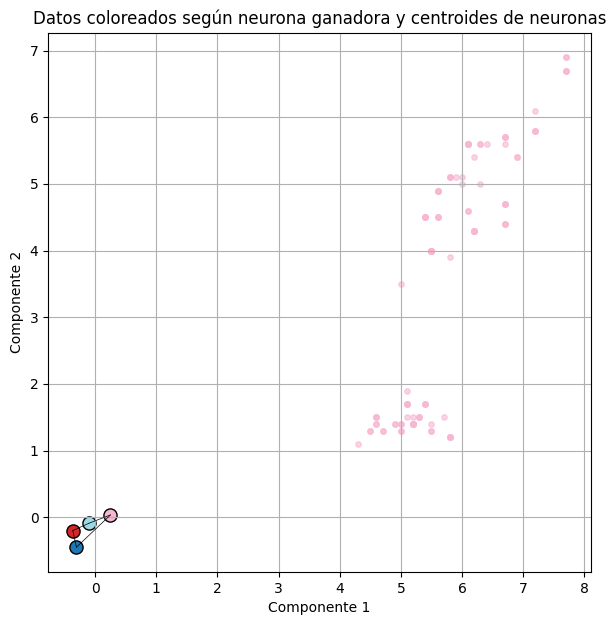

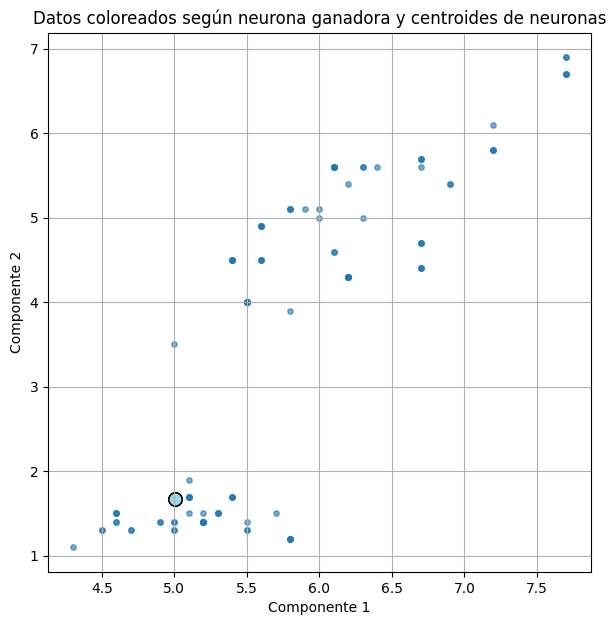

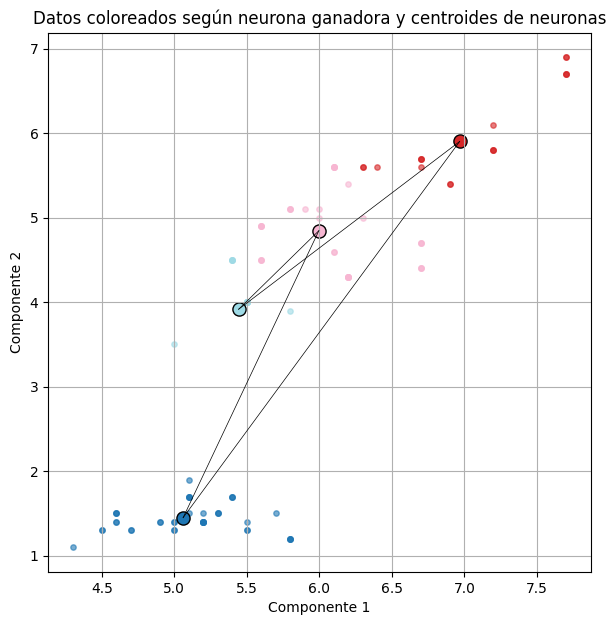

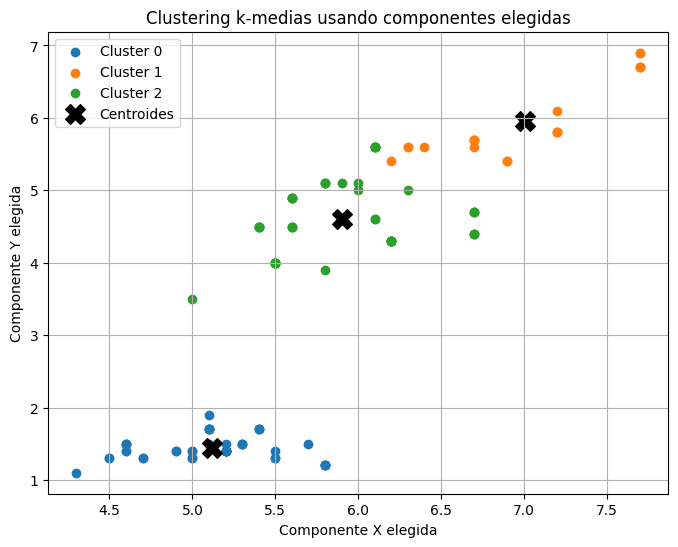

In [62]:
####################################################################
# Carga y preprocesamiento de datos
x = []
y = []

with open('iris81_trn.csv', mode='r', encoding='utf-8') as archivo:
    lector = csv.reader(archivo)
    next(lector)  # saltea encabezado si lo tiene
    for fila in lector:
        # entradas: columnas 0 a 3
        x1, x2, x3, x4 = map(float, fila[:4])
        x.append([x1, x2, x3, x4])
        
        # salidas: columnas 4 a 6 (asumo que son 3 columnas con one-hot)
        y1, y2, y3 = map(float, fila[4:7])
        y.append([y1, y2, y3])

x = np.array(x)
y = np.array(y)
y_true = np.argmax(y, axis=1)
####################################################################

# Ejecutamos k-means
labels, centroids, inertia = k_means(x, k=3)



epochs = 1000
x = np.array(x)
matriz = matriz_vectores_2d(2, 2, 4)
submatriz = matriz[:, :, [0, 2]]
datos_proy = x[:, [0, 2]]  # shape = (n_samples, 2)

graficar_datos_y_neuronas(submatriz, datos_proy)
for epoch in range(epochs):
    radio_vecindad = vec_fun(epoch)  # Función para el radio de vecindad dependiendo de la etapa
    tasa_de_aprendizaje = mu_fun(epoch)  # Función para la constante de aprendizaje dependiendo de la etapa
    for xi in x:  # xi es cada vector de entrada (2,)
        matriz = actualizar_pesos(matriz, xi, tasa_de_aprendizaje, radio_vecindad)
    
    submatriz = matriz[:, :, [0, 2]]
    if epoch % 500 == 0:
        graficar_datos_y_neuronas(submatriz, datos_proy)



############GRAFICO K-MEANS ####################################

# Supongamos X.shape = (n_samples, 4) y labels del k-means
# Por ejemplo, elegimos graficar columna 0 y columna 2
componente_x = x[:, 0]  # tu primera coordenada elegida
componente_y = x[:, 2]  # tu segunda coordenada elegida

# Centroides también seleccionamos las mismas columnas
centroides_x = centroids[:, 0]
centroides_y = centroids[:, 2]

plt.figure(figsize=(8,6))
for cluster in range(3):  # k=3
    plt.scatter(componente_x[labels==cluster],
                componente_y[labels==cluster],
                label=f'Cluster {cluster}')

# Graficar centroides
plt.scatter(centroides_x, centroides_y, c='black', marker='X', s=200, label='Centroides')

plt.xlabel('Componente X elegida')
plt.ylabel('Componente Y elegida')
plt.title('Clustering k-medias usando componentes elegidas')
plt.legend()
plt.grid(True)
plt.show()



In [61]:

filas, columnas = matriz.shape[:2]

#  Inicializamos la asignación de clases para cada neurona
asignacion_clase = np.full((filas, columnas), -1, dtype=int)  # -1 significa sin datos
clases_por_neurona = [[[] for _ in range(columnas)] for _ in range(filas)]

# Para cada dato de entrada, encontramos la BMU y guardamos la clase
for dato, clase_real in zip(x, y_true):
    # Distancia entre la entrada y todas las neuronas
    distancias = np.linalg.norm(matriz - dato, axis=2)
    # Coordenadas de la neurona más cercana (BMU)
    fila_bmu, col_bmu = np.unravel_index(np.argmin(distancias), distancias.shape)
    # Guardamos la clase en esa neurona
    clases_por_neurona[fila_bmu][col_bmu].append(clase_real)

# Determinamos la clase dominante en cada neurona
for i in range(filas):
    for j in range(columnas):
        if clases_por_neurona[i][j]:
            # La clase más común
            asignacion_clase[i, j] = Counter(clases_por_neurona[i][j]).most_common(1)[0][0]

# Predicción para cada dato usando la BMU
y_pred_som = []
for dato in x:
    distancias = np.linalg.norm(matriz - dato, axis=2)
    fila_bmu, col_bmu = np.unravel_index(np.argmin(distancias), distancias.shape)
    y_pred_som.append(asignacion_clase[fila_bmu, col_bmu])



In [46]:

clases = ["Setosa", "Versicolor", "Virginica"]

# 1️⃣ y_true vs SOM
contingencia_true_som = confusion_matrix(y_true, y_pred_som)
df_true_som = pd.DataFrame(contingencia_true_som,
                           index=clases,
                           columns=clases)
print("y_true vs SOM")
print(df_true_som)
print()

# 2️⃣ y_true vs K-means
contingencia_true_kmeans = confusion_matrix(y_true, labels)
df_true_kmeans = pd.DataFrame(contingencia_true_kmeans,
                              index=clases,
                              columns=clases)
print("y_true vs K-means")
print(df_true_kmeans)
print()

# 3️⃣ K-means vs SOM
contingencia_kmeans_som = confusion_matrix(labels, y_pred_som)
df_kmeans_som = pd.DataFrame(contingencia_kmeans_som,
                             index=clases,   # filas = K-means
                             columns=clases) # columnas = SOM
print("K-means vs SOM")
print(df_kmeans_som)


y_true vs SOM
            Setosa  Versicolor  Virginica
Setosa          18          16          0
Versicolor       0          32          0
Virginica        0           0         44

y_true vs K-means
            Setosa  Versicolor  Virginica
Setosa          10           0         24
Versicolor      32           0          0
Virginica        0          44          0

K-means vs SOM
            Setosa  Versicolor  Virginica
Setosa           0          42          0
Versicolor       0           0         44
Virginica       18           6          0
